In [1]:
import pandas as pd
import numpy as np
import re
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
df = pd.read_csv("cyber security data.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 13)


In [3]:
print("Columns:")
print(df.columns.tolist())
print("\nMissing Values:")
print(df.isnull().sum())

Columns:
['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'bytes_sent', 'bytes_received', 'user_agent', 'url', 'is_internal_traffic', 'label', 'attack_type']

Missing Values:
timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64


In [4]:
print("Total Rows:", len(df))
print("\nURL Available:")
print(df["url"].notna().sum())
print("\nURL Missing:")
print(df["url"].isna().sum())

Total Rows: 10000

URL Available:
6768

URL Missing:
3232


In [5]:
df_B = df[df["url"].notna()].copy()
print("Model B Dataset Shape:", df_B.shape)

Model B Dataset Shape: (6768, 13)


In [6]:
print("Model B Label Counts:")
print(df_B["label"].value_counts())
print("\nModel B Label Percentage:")
print(df_B["label"].value_counts(normalize=True) * 100)

Model B Label Counts:
label
0    6499
1     269
Name: count, dtype: int64

Model B Label Percentage:
label
0    96.025414
1     3.974586
Name: proportion, dtype: float64


In [7]:
print(df_B["url"].head(10))

0                  https://webmail.corp/login?id=385071
1     https://portal.example.org/owa/auth/logon.aspx...
3             https://webmail.corp/phpmyadmin?id=114701
4       https://portal.example.org/config.php?id=345569
6                https://internal.bank.local/?id=432022
7             https://webmail.corp/phpmyadmin?id=957608
8           https://internal.bank.local/admin?id=567716
10    https://api.service.io/owa/auth/logon.aspx?id=...
16        https://api.service.io/wp-login.php?id=407810
18    https://internal.bank.local/manager/html?id=20...
Name: url, dtype: object


In [8]:
print("\nUnique URLs:", df_B["url"].nunique())
print("Total URLs :", len(df_B))


Unique URLs: 6768
Total URLs : 6768


In [9]:
def extract_url_features(url):
    url = str(url)
    features = {}

    # Basic length
    features["url_length"] = len(url)

    # Character counts
    features["url_dots"] = url.count(".")
    features["url_slashes"] = url.count("/")
    features["url_hyphens"] = url.count("-")
    features["url_underscores"] = url.count("_")
    features["url_at"] = url.count("@")
    features["url_question"] = url.count("?")
    features["url_equal"] = url.count("=")
    features["url_ampersand"] = url.count("&")
    features["url_percent"] = url.count("%")

    # Digit count
    features["url_digits"] = sum(c.isdigit() for c in url)

    # Alphabet count
    features["url_letters"] = sum(c.isalpha() for c in url)

    # Special characters
    features["url_special_chars"] = sum(
        not c.isalnum() for c in url
    )

    # HTTPS
    features["is_https"] = int(url.lower().startswith("https"))

    # HTTP
    features["is_http"] = int(url.lower().startswith("http"))

    # Query parameter presence
    features["has_query"] = int("?" in url)

    # Fragment presence
    features["has_fragment"] = int("#" in url)

    # Possible IP address in URL
    features["has_ip"] = int(
        bool(re.search(
            r"https?://(?:\d{1,3}\.){3}\d{1,3}",
            url
        ))
    )

    return features

In [10]:
url_features = df_B["url"].apply(extract_url_features)
url_features = pd.DataFrame(
    url_features.tolist(),
    index=df_B.index
)
print("URL Features Shape:", url_features.shape)
print("\nURL Features:")
print(url_features.columns.tolist())

URL Features Shape: (6768, 18)

URL Features:
['url_length', 'url_dots', 'url_slashes', 'url_hyphens', 'url_underscores', 'url_at', 'url_question', 'url_equal', 'url_ampersand', 'url_percent', 'url_digits', 'url_letters', 'url_special_chars', 'is_https', 'is_http', 'has_query', 'has_fragment', 'has_ip']


In [11]:
url_features.head()

,url_length,url_dots,url_slashes,url_hyphens,url_underscores,url_at,url_question,url_equal,url_ampersand,url_percent,url_digits,url_letters,url_special_chars,is_https,is_http,has_query,has_fragment,has_ip
0,36,1,3,0,0,0,1,1,0,0,6,23,7,1,1,1,0,0
1,56,3,5,0,0,0,1,1,0,0,6,39,11,1,1,1,0,0
3,41,1,3,0,0,0,1,1,0,0,6,28,7,1,1,1,0,0
4,47,3,3,0,0,0,1,1,0,0,6,32,9,1,1,1,0,0
6,38,2,3,0,0,0,1,1,0,0,6,24,8,1,1,1,0,0


In [12]:
df_B_features = df_B.drop(columns=["url"]).copy()
df_B_features = pd.concat(
    [df_B_features, url_features],
    axis=1
)
print("New Shape:", df_B_features.shape)

New Shape: (6768, 30)


In [13]:
X_B = df_B_features.drop(
    columns=["label", "attack_type"]
)
y_B = df_B_features["label"]

print("X_B Shape:", X_B.shape)
print("y_B Shape:", y_B.shape)

X_B Shape: (6768, 28)
y_B Shape: (6768,)


In [14]:
X_B["timestamp"] = pd.to_datetime(
    X_B["timestamp"]
)
X_B["hour"] = X_B["timestamp"].dt.hour
X_B["day_of_week"] = X_B["timestamp"].dt.dayofweek
X_B["month"] = X_B["timestamp"].dt.month
X_B = X_B.drop(columns=["timestamp"])
print("Timestamp processing completed.")

Timestamp processing completed.


In [15]:
X_B = X_B.drop(
    columns=["src_ip", "dst_ip"]
)
print("IP columns removed.")

IP columns removed.


In [16]:
print("Final Model B Features:")
for feature in X_B.columns:
    print("-", feature)
print("\nTotal Features:", len(X_B.columns))

Final Model B Features:
- src_port
- dst_port
- protocol
- bytes_sent
- bytes_received
- user_agent
- is_internal_traffic
- url_length
- url_dots
- url_slashes
- url_hyphens
- url_underscores
- url_at
- url_question
- url_equal
- url_ampersand
- url_percent
- url_digits
- url_letters
- url_special_chars
- is_https
- is_http
- has_query
- has_fragment
- has_ip
- hour
- day_of_week
- month

Total Features: 28


In [17]:
print("Missing Values in Model B:")
print(X_B.isnull().sum())

Missing Values in Model B:
src_port               0
dst_port               0
protocol               0
bytes_sent             0
bytes_received         0
user_agent             0
is_internal_traffic    0
url_length             0
url_dots               0
url_slashes            0
url_hyphens            0
url_underscores        0
url_at                 0
url_question           0
url_equal              0
url_ampersand          0
url_percent            0
url_digits             0
url_letters            0
url_special_chars      0
is_https               0
is_http                0
has_query              0
has_fragment           0
has_ip                 0
hour                   0
day_of_week            0
month                  0
dtype: int64


In [18]:
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y_B,
    test_size=0.20,
    random_state=42,
    stratify=y_B
)
print("Training Data:", X_train_B.shape)
print("Testing Data :", X_test_B.shape)

Training Data: (5414, 28)
Testing Data : (1354, 28)


In [19]:
numeric_features_B = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "hour",
    "day_of_week",
    "month",

    "url_length",
    "url_dots",
    "url_slashes",
    "url_hyphens",
    "url_underscores",
    "url_at",
    "url_question",
    "url_equal",
    "url_ampersand",
    "url_percent",
    "url_digits",
    "url_letters",
    "url_special_chars",
    "is_https",
    "is_http",
    "has_query",
    "has_fragment",
    "has_ip"
]

In [20]:
categorical_features_B = [
    "protocol",
    "user_agent",
    "is_internal_traffic"
]

In [21]:
numeric_pipeline_B = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [22]:
categorical_pipeline_B = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [23]:
preprocessor_B = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline_B,
        numeric_features_B
    ),
    
    (
        "categorical",
        categorical_pipeline_B,
        categorical_features_B
    )
])

In [24]:
model_B = Pipeline([
    (
        "preprocessor",
        preprocessor_B
    ),
    
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

print("Model B created successfully!")

Model B created successfully!


In [25]:
model_B.fit(
    X_train_B,
    y_train_B
)

print("Model B training completed successfully!")

Model B training completed successfully!


In [26]:
y_pred_B = model_B.predict(X_test_B)

print("First 20 Predictions:")
print(y_pred_B[:20])

First 20 Predictions:
[0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0]


In [27]:
y_prob_B = model_B.predict_proba(
    X_test_B
)[:, 1]

print("First 20 Attack Probabilities:")
print(y_prob_B[:20])

First 20 Attack Probabilities:
[0.39369784 0.4613891  0.30610708 0.67388892 0.42674749 0.15531941
 0.16836827 0.48657157 0.28335163 0.24341458 0.23730842 0.31752198
 0.39422232 0.50116186 0.42517636 0.50826854 0.32312599 0.53040993
 0.46989119 0.13535147]


In [28]:
accuracy_B = accuracy_score(
    y_test_B,
    y_pred_B
)

precision_B = precision_score(
    y_test_B,
    y_pred_B
)

recall_B = recall_score(
    y_test_B,
    y_pred_B
)

f1_B = f1_score(
    y_test_B,
    y_pred_B
)

roc_auc_B = roc_auc_score(
    y_test_B,
    y_prob_B
)

print("Model B Performance")
print("-------------------")

print("Accuracy :", accuracy_B)
print("Precision:", precision_B)
print("Recall   :", recall_B)
print("F1 Score :", f1_B)
print("ROC-AUC  :", roc_auc_B)

Model B Performance
-------------------
Accuracy : 0.7437223042836041
Precision: 0.09192200557103064
Recall   : 0.6111111111111112
F1 Score : 0.15980629539951574
ROC-AUC  : 0.7738461538461537


In [29]:
print("Model B Performance (%)")
print("-----------------------")

print("Accuracy :", round(accuracy_B * 100, 2), "%")
print("Precision:", round(precision_B * 100, 2), "%")
print("Recall   :", round(recall_B * 100, 2), "%")
print("F1 Score :", round(f1_B * 100, 2), "%")
print("ROC-AUC  :", round(roc_auc_B * 100, 2), "%")

Model B Performance (%)
-----------------------
Accuracy : 74.37 %
Precision: 9.19 %
Recall   : 61.11 %
F1 Score : 15.98 %
ROC-AUC  : 77.38 %


In [30]:
print(
    classification_report(
        y_test_B,
        y_pred_B,
        target_names=["Benign", "Attack"]
    )
)

              precision    recall  f1-score   support

      Benign       0.98      0.75      0.85      1300
      Attack       0.09      0.61      0.16        54

    accuracy                           0.74      1354
   macro avg       0.54      0.68      0.50      1354
weighted avg       0.94      0.74      0.82      1354



In [31]:
cm_B = confusion_matrix(
    y_test_B,
    y_pred_B
)

print("Confusion Matrix:")
print(cm_B)

Confusion Matrix:
[[974 326]
 [ 21  33]]


In [32]:
os.makedirs("graphs", exist_ok=True)

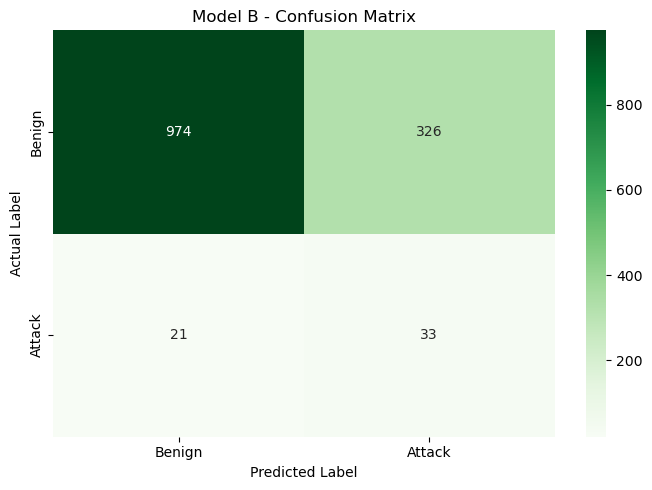

In [33]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_B,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.title("Model B - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "PNG FOLDER/model_B_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
model_B_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    
    "Score": [
        accuracy_B,
        precision_B,
        recall_B,
        f1_B,
        roc_auc_B
    ]
})

model_B_results["Percentage"] = (
    model_B_results["Score"] * 100
)

model_B_results

,Metric,Score,Percentage
0,Accuracy,0.743722,74.372230
1,Precision,0.091922,9.192201
2,Recall,0.611111,61.111111
3,F1 Score,0.159806,15.980630
4,ROC-AUC,0.773846,77.384615


In [35]:
joblib.dump(
    model_B,
    "model_B.pkl"
)

print("Model B saved successfully as model_B.pkl")

Model B saved successfully as model_B.pkl


In [36]:
print("===================================")
print("          MODEL B SUMMARY")
print("===================================")

print("Total Dataset Rows :", len(df))
print("Model B Rows       :", len(df_B))
print("Training Rows      :", len(X_train_B))
print("Testing Rows       :", len(X_test_B))

print("\nURL Status:")
print("URL Available      :", df["url"].notna().sum())
print("URL Missing        :", df["url"].isna().sum())

print("\nURL Features Added:")
for feature in url_features.columns:
    print("-", feature)

print("\nPerformance:")
print("Accuracy  :", round(accuracy_B * 100, 2), "%")
print("Precision :", round(precision_B * 100, 2), "%")
print("Recall    :", round(recall_B * 100, 2), "%")
print("F1 Score  :", round(f1_B * 100, 2), "%")
print("ROC-AUC   :", round(roc_auc_B * 100, 2), "%")

print("\nModel B completed successfully!")

          MODEL B SUMMARY
Total Dataset Rows : 10000
Model B Rows       : 6768
Training Rows      : 5414
Testing Rows       : 1354

URL Status:
URL Available      : 6768
URL Missing        : 3232

URL Features Added:
- url_length
- url_dots
- url_slashes
- url_hyphens
- url_underscores
- url_at
- url_question
- url_equal
- url_ampersand
- url_percent
- url_digits
- url_letters
- url_special_chars
- is_https
- is_http
- has_query
- has_fragment
- has_ip

Performance:
Accuracy  : 74.37 %
Precision : 9.19 %
Recall    : 61.11 %
F1 Score  : 15.98 %
ROC-AUC   : 77.38 %

Model B completed successfully!
